In [1]:
# =============================================================
# ERA COMPARISON PROJECT - Notebook 3: Era 2 Classical ML
#
# Era 2 Philosophy: Instead of human-written rules, we let the
# machine find patterns in historical data automatically.
#
# Key shift from Era 1:
# - Era 1: Human says "when MA20 > MA50, buy"
# - Era 2: Machine looks at thousands of historical days and
#   learns by itself which conditions tend to precede price rises
#
# Algorithm: Random Forest Classifier
# - Trains hundreds of decision trees on random subsets of data
# - Each tree votes on whether tomorrow will go up or down
# - Final prediction = majority vote across all trees
# =============================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

ticker = 'AAPL'
data = yf.download(ticker, start='2014-01-01', end='2024-01-01')
prices = data['Close'].squeeze()
volume = data['Volume'].squeeze()

[*********************100%***********************]  1 of 1 completed


In [2]:
# =============================================================
# FEATURE ENGINEERING
#
# Random Forest cannot read raw prices directly.
# We need to convert prices into "features" - numerical
# descriptions of the current market state.
#
# Think of features as answering these questions:
# - How has the stock moved recently? (return features)
# - Is the price above or below its average? (MA ratio features)
# - Is the stock overbought or oversold? (RSI feature)
# - How volatile has the market been? (volatility feature)
# - Is trading volume unusually high or low? (volume feature)
#
# Target variable: will tomorrow's price be higher than today's?
# 1 = yes (price goes up), 0 = no (price goes down or flat)
# =============================================================

def build_features(prices, volume):
    """
    Convert raw price and volume data into ML-ready features.
    Each row represents one trading day's market state.
    """
    df = pd.DataFrame()
    
    # --- Momentum Features ---
    # How much has the stock moved over the last N days?
    # Captures short-term and medium-term price momentum
    for lag in [1, 2, 3, 5, 10]:
        df[f'return_{lag}d'] = prices.pct_change(lag)
    
    # --- Moving Average Ratio Features ---
    # Where is the current price relative to its N-day average?
    # Positive value = price is above average (bullish signal)
    # Negative value = price is below average (bearish signal)
    for window in [10, 20, 50]:
        df[f'ma_ratio_{window}'] = prices / prices.rolling(window).mean() - 1
    
    # --- RSI Feature ---
    # Reuse RSI from Era 1, but now as an INPUT to the model
    # rather than directly generating buy/sell signals.
    # The model decides how to use it - we don't hardcode thresholds.
    delta = prices.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    df['rsi'] = 100 - (100 / (1 + gain / loss))
    
    # --- Volatility Feature ---
    # Standard deviation of daily returns over last 20 days
    # High volatility = uncertain market, model should know this
    df['volatility_20'] = prices.pct_change().rolling(20).std()
    
    # --- Volume Feature ---
    # Is today's trading volume higher or lower than usual?
    # Unusually high volume often signals important price moves
    df['volume_ratio'] = volume / volume.rolling(20).mean()
    
    # --- Target Variable ---
    # shift(-1) looks at TOMORROW's price
    # If tomorrow > today, label = 1 (up), else label = 0 (down)
    # This is what the model tries to predict
    df['target'] = (prices.shift(-1) > prices).astype(int)
    
    # Drop rows with NaN values created by rolling calculations
    df = df.dropna()
    return df

df = build_features(prices, volume)
print(f"Dataset shape: {df.shape}")
print(f"Features: {[c for c in df.columns if c != 'target']}")
print(f"\nTarget distribution:")
print(df['target'].value_counts())

Dataset shape: (2467, 12)
Features: ['return_1d', 'return_2d', 'return_3d', 'return_5d', 'return_10d', 'ma_ratio_10', 'ma_ratio_20', 'ma_ratio_50', 'rsi', 'volatility_20', 'volume_ratio']

Target distribution:
target
1    1306
0    1161
Name: count, dtype: int64


In [3]:
# =============================================================
# TRAIN/TEST SPLIT
#
# CRITICAL: We must split by TIME, not randomly.
#
# Why? If we randomly shuffle the data and split, we might
# train on data from 2022 and test on data from 2019.
# The model would effectively be "seeing the future" during
# training - this is called lookahead bias.
#
# In real trading, you only know the past.
# So we train on the first 80% of history,
# and test on the last 20% - data the model has never seen.
#
# This gives us an honest estimate of real-world performance.
# =============================================================

feature_cols = [c for c in df.columns if c != 'target']
X = df[feature_cols]  # input features
y = df['target']      # what we're trying to predict

# Split at 80% mark, preserving time order
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Training set: {len(X_train)} days")
print(f"Test set: {len(X_test)} days")
print(f"Training period: {X_train.index[0].date()} to {X_train.index[-1].date()}")
print(f"Test period: {X_test.index[0].date()} to {X_test.index[-1].date()}")

# =============================================================
# TRAIN RANDOM FOREST
#
# Key hyperparameters explained:
# - n_estimators=200: build 200 trees and take majority vote
#   More trees = more stable predictions, but slower training
# - max_depth=5: each tree can only ask 5 questions deep
#   Limits complexity to prevent overfitting
# - min_samples_leaf=20: each leaf node needs at least 20 samples
#   Prevents the model from memorizing individual data points
# - random_state=42: fixes the random seed for reproducibility
#   Anyone running this code gets the same result
# =============================================================

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=20,
    random_state=42
)
model.fit(X_train, y_train)

# Evaluate on test set (data the model never saw during training)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nPrediction Accuracy: {accuracy:.2%}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Training set: 1973 days
Test set: 494 days
Training period: 2014-03-14 to 2022-01-11
Test period: 2022-01-12 to 2023-12-29

Prediction Accuracy: 54.66%

Detailed Report:
              precision    recall  f1-score   support

           0       0.58      0.27      0.36       241
           1       0.54      0.81      0.65       253

    accuracy                           0.55       494
   macro avg       0.56      0.54      0.51       494
weighted avg       0.56      0.55      0.51       494



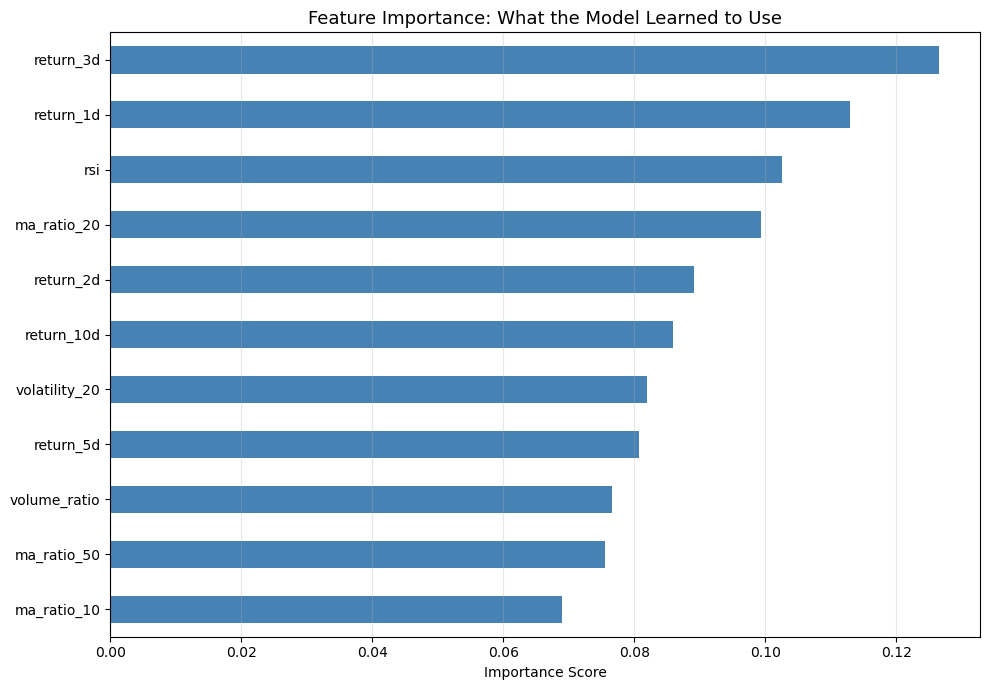

In [4]:
# =============================================================
# FEATURE IMPORTANCE
#
# After training, Random Forest can tell us which features
# it found most useful for making predictions.
#
# Importance score = how much a feature reduced prediction error
# across all 200 trees, on average.
#
# This chart answers: "what does the model think matters most?"
# Compare this to Era 1, where WE decided what matters.
# Here, the machine decided.
# =============================================================

importance = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance: What the Model Learned to Use',
             fontsize=13)
ax.set_xlabel('Importance Score')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../results/04_feature_importance.png', dpi=150)
plt.show()

=== Era 2: Random Forest Strategy (Test Period) ===
Total Return (%): 49.12
Annual Return (%): 22.61
Max Drawdown (%): -19.65
Sharpe Ratio: 0.88


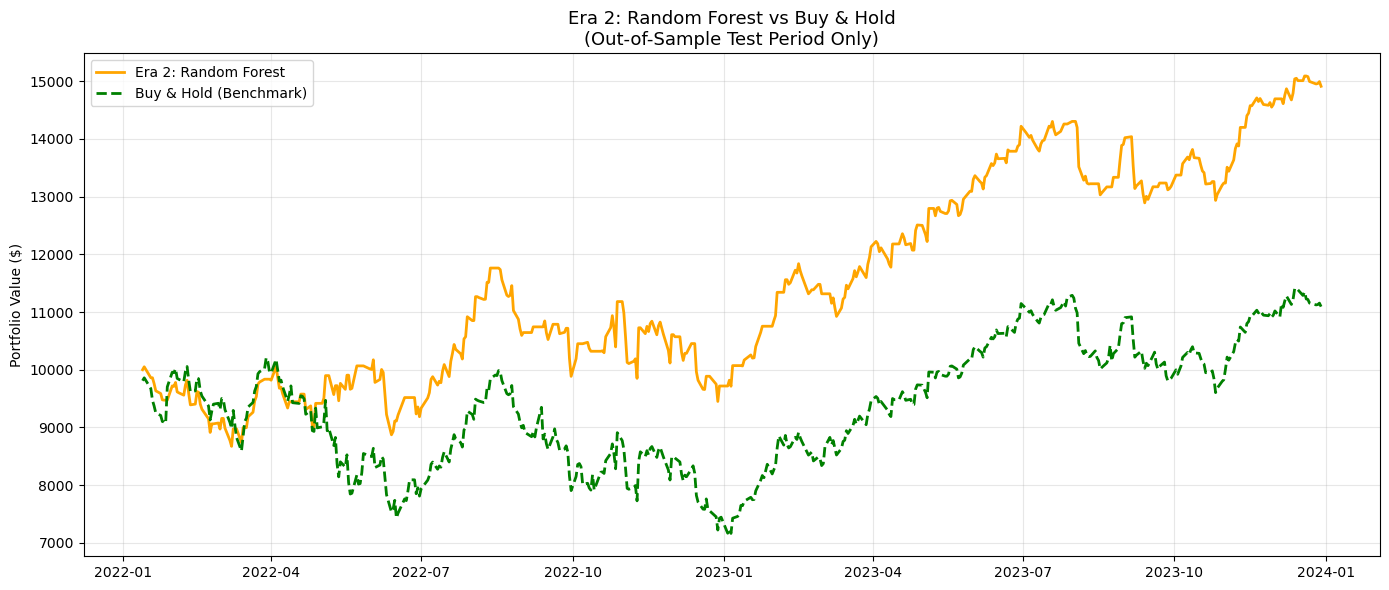

In [5]:
# =============================================================
# BACKTEST: ERA 2 RANDOM FOREST
#
# The model's predictions become our trading signal:
# - Predicted 1 (price will go up tomorrow) -> hold position
# - Predicted 0 (price will go down tomorrow) -> stay in cash
#
# Important: we only backtest on the TEST set
# Testing on training data would be like grading a student
# on the exact questions they already studied - meaningless.
#
# We compare against Buy & Hold over the SAME test period
# to make the comparison fair.
# =============================================================

def backtest(prices, signal, initial_capital=10000):
    """
    Simulate trading strategy and compute performance metrics.
    See Notebook 2 for full documentation.
    """
    daily_returns = prices.pct_change()
    strategy_returns = signal.shift(1) * daily_returns
    portfolio = initial_capital * (1 + strategy_returns).cumprod()
    buy_and_hold = initial_capital * (1 + daily_returns).cumprod()
    total_return = (portfolio.iloc[-1] / initial_capital - 1) * 100
    n_years = len(prices) / 252
    annual_return = ((portfolio.iloc[-1] / initial_capital) ** (1/n_years) - 1) * 100
    rolling_max = portfolio.cummax()
    drawdown = (portfolio - rolling_max) / rolling_max
    max_drawdown = drawdown.min() * 100
    excess_returns = strategy_returns - 0.02/252
    sharpe = np.sqrt(252) * excess_returns.mean() / excess_returns.std()
    results = {
        'Total Return (%)': round(total_return, 2),
        'Annual Return (%)': round(annual_return, 2),
        'Max Drawdown (%)': round(max_drawdown, 2),
        'Sharpe Ratio': round(sharpe, 2)
    }
    return results, portfolio, buy_and_hold

# Convert model predictions to a pandas Series with dates as index
# This makes it compatible with our backtest function
test_prices = prices[X_test.index]
rf_signal = pd.Series(y_pred, index=X_test.index, dtype=float)

results_rf, portfolio_rf, buy_and_hold_test = backtest(test_prices, rf_signal)

print("=== Era 2: Random Forest Strategy (Test Period) ===")
for k, v in results_rf.items():
    print(f"{k}: {v}")

# --- Visualization ---
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(portfolio_rf.index, portfolio_rf,
        label='Era 2: Random Forest', color='orange', linewidth=2)
ax.plot(buy_and_hold_test.index, buy_and_hold_test,
        label='Buy & Hold (Benchmark)', color='green',
        linestyle='--', linewidth=2)

# Shade the test period to remind viewer this is out-of-sample data
ax.set_title('Era 2: Random Forest vs Buy & Hold\n(Out-of-Sample Test Period Only)',
             fontsize=13)
ax.set_ylabel('Portfolio Value ($)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/05_era2_rf_performance.png', dpi=150)
plt.show()